# Iterative Workflows in LangGraph: Generate-Evaluate-Optimize Loops

Every other notebook in this folder builds a strictly acyclic graph: nodes are wired together with `add_edge` or `add_conditional_edges` in a way that guarantees a `START` to `END` path visits each node at most once. Sequential chains run node A then B then C. Parallel graphs fan out and fan back in. Conditional graphs pick one of several branches. In all of those cases the graph is a directed acyclic graph (DAG) — there is no way to revisit a node once it has run.

This notebook introduces a graph that is not a DAG. It contains a cycle: an `evaluate` node can route back to an `optimize` node, whose output flows back into `evaluate` again. The graph keeps re-entering the same subset of nodes until a condition is satisfied. This is the "generate, evaluate, refine" pattern, and it is one of the most common building blocks in real LLM applications — draft an answer, critique it, improve it, critique again — because a single LLM call rarely produces an optimal result on the first attempt, but an LLM is quite good at judging and improving its own (or another model's) output when given a second pass.

## Why loops need an explicit termination condition

A cyclic graph only terminates when the routing function protecting the cycle returns a path to `END`. If that function only checked the quality signal (for example "has the critic approved the draft yet"), and the critic never approved it, the graph would keep invoking `optimize` and `evaluate` forever. This is the central risk of any loop-based workflow: it must be paired with a guaranteed exit condition that does not depend solely on quality, typically an iteration counter compared against a hard maximum. This notebook's state schema and router function are both built around that requirement, as the following cells will show in detail.

## Why this pattern matters for agentic workflows

Generate-evaluate-refine loops are a foundational primitive for agentic behavior: an agent that can inspect its own output, decide it is insufficient, and try again is exhibiting a rudimentary form of self-correction. The same cyclic-graph mechanics used here — a state that accumulates history, a node that evaluates against criteria, and a conditional edge that either loops or exits — reappear in more complex agents (tool-calling loops, ReAct-style reasoning loops, multi-agent critique loops). Understanding this small tweet-generation example is a direct stepping stone to understanding those larger systems.

## Imports

`StateGraph`, `START`, and `END` build and terminate the graph, the same as in the acyclic notebooks. `TypedDict` defines the state schema. `Literal` restricts a field to a fixed set of string values (used later for the `evaluation` field). `Annotated` attaches a reducer to a state field, which is what allows the tweet and feedback history lists to accumulate across loop iterations rather than being overwritten on each node call. `ChatOpenAI` provides the LLM clients, `SystemMessage`/`HumanMessage` construct chat prompts, and `operator` supplies `operator.add`, the reducer function used with `Annotated` to append list values together instead of replacing them.

In [2]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator

In [3]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

## Three separate LLM clients

`generator_llm`, `evaluator_llm`, and `optimizer_llm` are all instances of `gpt-4o-mini`, kept as three distinct Python objects even though they wrap the same underlying model. This separation mirrors the three distinct roles in the loop: one client drafts the tweet, one critiques it, and one rewrites it based on the critique. Using separate objects (rather than one shared LLM instance) keeps each role's configuration independent, so any of the three could later be swapped for a different model or given different parameters (temperature, model name) without touching the others.

In [4]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")


## The evaluation's structured-output schema

`TweetEvaluation` is a Pydantic `BaseModel` with two fields: `evaluation`, restricted by `Literal["approved", "needs_improvement"]` to exactly those two string values, and `feedback`, a free-text string. This schema is the contract the evaluator LLM must fill in — instead of parsing a critique out of unstructured text, the graph asks the LLM to return an object matching this exact shape. The `evaluation` field is what the router function reads to decide whether the loop should exit or continue, and the `feedback` field is what gets fed back into the optimizer node as the instruction for how to improve the tweet.

In [5]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

## Binding structured output to the evaluator

`structured_evaluator_llm` wraps `evaluator_llm` with `.with_structured_output(TweetEvaluation)`. This tells the underlying model to constrain its response so that it can be parsed directly into a `TweetEvaluation` instance, rather than returning a plain string that would need manual parsing. Every call made through `structured_evaluator_llm` returns a `TweetEvaluation` object with `.evaluation` and `.feedback` attributes already populated, which is exactly what the `evaluate_tweet` node relies on later.

In [6]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

## The state schema

`TweetState` is a `TypedDict` with eight fields:

- `topic`: the subject supplied to kick off the workflow.
- `tweet`: the current draft tweet, overwritten each time `generate_tweet` or `optimize_tweet` produces a new version.
- `evaluation`: the critic's verdict for the current draft, one of `"approved"` or `"needs_improvement"`.
- `feedback`: the critic's most recent feedback text for the current draft.
- `iteration`: a counter tracking how many optimization passes have occurred.
- `max_iteration`: the hard cap on optimization passes, supplied at invocation time.
- `tweet_history`: `Annotated[list[str], operator.add]` — every draft tweet ever produced, in order. Because the field is annotated with the `operator.add` reducer, each node's returned `{'tweet_history': [response]}` is concatenated onto the existing list rather than replacing it.
- `feedback_history`: the same accumulation pattern applied to every piece of feedback the critic has given.

`iteration` and `max_iteration` together are the loop's termination safeguard: `iteration` only increases inside `optimize_tweet`, and the router compares it against `max_iteration` on every pass through `evaluate`. The two history lists are the audit trail that lets you see every draft and every critique the loop produced, not just the final result.

In [7]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

## The generation node

`generate_tweet` builds a two-message prompt: a `SystemMessage` casting the model as "a funny and clever Twitter/X influencer," and a `HumanMessage` instructing it to write a tweet about `state['topic']` under an explicit rule set — no question-answer format, a 280-character maximum, observational humor/irony/sarcasm/cultural references, meme logic and punchlines, and plain everyday English. The prompt is sent to `generator_llm` (not the structured or evaluator client), and `.content` extracts the raw text response.

The node returns a partial state update: `{'tweet': response, 'tweet_history': [response]}`. Because `tweet_history` is annotated with `operator.add`, this single-element list is appended to whatever history already exists rather than replacing it — on the very first call the history starts empty, so this establishes the first entry.

In [8]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

## The evaluation node and its scoring logic

`evaluate_tweet` casts the model as "a ruthless, no-laugh-given Twitter critic" and asks it to judge `state['tweet']` against five named criteria: originality, humor, punchiness, virality potential, and format. The prompt also lists explicit auto-reject conditions: question-answer phrasing, exceeding 280 characters, a traditional setup-punchline structure, or a generic/deflating closing line. The prompt instructs the model to respond only in the structured format defined by `TweetEvaluation` — this is enforced by calling `structured_evaluator_llm.invoke(messages)` rather than the plain `evaluator_llm`, so the return value is already a parsed `TweetEvaluation` object with `.evaluation` and `.feedback` attributes rather than raw text.

The node returns `{'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}`. The first two fields overwrite the current-draft verdict and feedback outright (no reducer on those fields in the state schema), while `feedback_history` accumulates via `operator.add` just like `tweet_history` does. Note that this node does not touch `iteration` — the counter is only advanced inside `optimize_tweet`.

In [9]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

## The optimization node and the iteration counter

`optimize_tweet` casts the model as one that "punches up tweets for virality and humor based on given feedback." Its `HumanMessage` includes the critic's `state['feedback']`, the original `state['topic']`, and the current `state['tweet']`, and asks for a rewritten tweet that avoids Q&A style and stays under 280 characters. The call goes to `optimizer_llm`, a client distinct from both the generator and the evaluator.

This node performs the increment that drives the loop toward termination: `iteration = state['iteration'] + 1`. The returned update is `{'tweet': response, 'iteration': iteration, 'tweet_history': [response]}` — the tweet is overwritten with the new draft, the iteration counter is overwritten with its incremented value, and the new draft is appended to `tweet_history` via the `operator.add` reducer. Control then flows back to `evaluate` (via the edge defined later), which is what turns this sequence of nodes into a cycle rather than a straight line.

In [21]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

## The router function and the max-iteration safeguard

`route_evaluation` is the function that decides whether the loop continues or exits. Its logic is a single condition: return `'approved'` if `state['evaluation'] == 'approved'` **or** `state['iteration'] >= state['max_iteration']`; otherwise return `'needs_improvement'`. The `or` is what prevents an infinite loop — even if the critic never approves a draft, once `iteration` reaches `max_iteration` the function is forced to return `'approved'` regardless of the actual evaluation verdict, sending the graph to `END`. This is the hard safeguard referenced in the introduction: quality alone does not control termination, a bounded counter does.

Note that the string `'approved'` returned here is being reused as a routing key, not as a literal claim that the tweet was approved by the critic — it is simply the branch name that leads to `END` in the conditional edge mapping defined in the next cell.

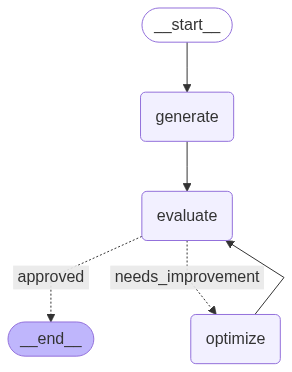

In [23]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

## Building the cyclic graph and compiling it

The graph is constructed with `StateGraph(TweetState)` and three nodes: `generate` (`generate_tweet`), `evaluate` (`evaluate_tweet`), and `optimize` (`optimize_tweet`).

The edges are:

- `START -> generate`: every run begins with a fresh draft.
- `generate -> evaluate`: the first draft is always evaluated.
- `evaluate -> route_evaluation -> {'approved': END, 'needs_improvement': 'optimize'}`: a conditional edge where the router's return value selects the next node. If it returns `'approved'`, the graph terminates at `END`. If it returns `'needs_improvement'`, control passes to `optimize`.
- `optimize -> evaluate`: a plain edge that sends every optimized draft back to the evaluator.

This last edge is what creates the cycle: `evaluate` can lead to `optimize`, and `optimize` unconditionally leads back to `evaluate`, so the pair of nodes can be revisited an arbitrary number of times (bounded by `max_iteration` via the router). `generate` itself is never re-entered — only the evaluate/optimize pair loops.

`graph.compile()` produces the runnable `workflow` object, identical in kind to the compiled graphs in the other notebooks; displaying `workflow` renders the graph structure, which for this notebook will visibly show the back-edge from `optimize` to `evaluate`.

In [27]:
initial_state = {
    "topic": "AI",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

## Invoking the workflow

`initial_state` supplies `topic: "AI"`, `iteration: 1`, and `max_iteration: 5`. Note that `iteration` starts at `1` rather than `0` — since `optimize_tweet` is the only node that increments it, and `route_evaluation` compares it against `max_iteration` with `>=`, this starting value effectively limits the run to at most 4 optimization passes before the counter forces approval (though the loop can also exit earlier if the critic approves a draft). `tweet`, `evaluation`, `feedback`, `tweet_history`, and `feedback_history` are all omitted from `initial_state` and are populated as the graph executes.

`workflow.invoke(initial_state)` runs the graph to completion — `generate` produces a first draft, `evaluate` scores it, and if not approved, `optimize`/`evaluate` alternate until either an approval or the iteration cap is hit — returning the final accumulated state as `result`.

In [28]:
result

{'topic': 'AI',
 'tweet': 'AI is like that one friend who claims they can do everything but just ends up playing chess while we’re all waiting for them to make dinner. At this point, I’d settle for a robot that knows how to microwave pizza without setting off my fire alarm. 🍕🔥 #TechStruggles',
 'evaluation': 'approved',
 'feedback': 'This tweet is quite original, as the analogy of AI to a friend who fails at basic tasks while showing off more complex skills is a refreshing take on the prevalent tech conversations. The humor effectively lands, particularly with the relatable imagery of waiting for dinner while someone just plays chess. It’s punchy enough to grab attention and likely to encourage shares due to the common theme of technological frustration, making it both relatable and shareable. Additionally, the formatting is perfect, adhering to the character limit and avoiding traditional joke structures.',
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['AI is like that one 

## Interpreting the output

Printing `result` shows the final state after the graph reached `END`. In the captured run, `evaluation` is `'approved'` and `iteration` remains `1`, meaning the very first generated draft was approved by the critic on the first evaluation pass — the loop never entered `optimize` at all. `tweet_history` contains exactly one entry (the original draft), and `feedback_history` contains exactly one entry (the critic's approving feedback), confirming no optimization cycle ran. Had the first draft been rejected, `tweet_history` and `feedback_history` would each have grown by one additional entry per pass through `optimize`/`evaluate`, and `iteration` would show how many optimization passes actually occurred before either approval or the `max_iteration` cutoff.

This result illustrates that the loop is conditional, not mandatory: the cyclic edge exists in the graph's structure, but whether it is ever traversed depends entirely on the evaluator's verdict at runtime.

In [29]:
for tweet in result['tweet_history']:
    print(tweet)

AI is like that one friend who claims they can do everything but just ends up playing chess while we’re all waiting for them to make dinner. At this point, I’d settle for a robot that knows how to microwave pizza without setting off my fire alarm. 🍕🔥 #TechStruggles


## Reading the draft-by-draft trace

Iterating over `result['tweet_history']` and printing each entry surfaces the full sequence of drafts the loop produced, in the order they were generated, independent of whatever the final `tweet` field holds. This is the practical value of accumulating history with `operator.add`: without it, each node's return value would simply overwrite `tweet` and every intermediate draft would be lost once the graph moved on. Here, because the first draft was approved immediately, the printed history contains only that single tweet; in a run where the loop iterated multiple times, this cell would print one line per draft, letting you see how the tweet evolved from the original generation through each successive optimization pass.

# Summary: the iterative refinement pattern

This notebook implements a three-role loop — generator, evaluator, optimizer — wired into a LangGraph `StateGraph` with a genuine cycle: `evaluate` conditionally routes to `optimize`, and `optimize` routes unconditionally back to `evaluate`. Structurally, this is the defining difference from every acyclic notebook in this folder: the graph can revisit the same nodes multiple times within a single invocation, driven by a runtime decision rather than a fixed sequence of edges.

The risk inherent to any such loop is that it has no natural stopping point if left to quality alone — a critic that is never satisfied would keep the graph running indefinitely. This notebook guards against that with two cooperating mechanisms: the `iteration` counter, incremented once per pass through `optimize_tweet`, and the `route_evaluation` router, which forces the `'approved'` (exit) branch once `iteration >= max_iteration` regardless of the actual evaluation verdict. The termination condition is therefore `evaluation == 'approved' OR iteration >= max_iteration` — quality-based early exit, backed by a hard iteration ceiling.

The two `Annotated[list[str], operator.add]` fields, `tweet_history` and `feedback_history`, turn the loop into an auditable process: every draft and every critique survive in state instead of being overwritten, which is what let the final cells inspect the full evolution of the tweet rather than only its last version.

This generate-evaluate-refine structure is a small but complete instance of the same mechanics that underlie larger agentic systems: a component that produces output, a component that judges it against explicit criteria, a bounded loop that allows retrying, and a state that accumulates a trace of the attempt. Tool-calling agent loops, ReAct-style reasoning loops, and multi-agent critique systems all extend this same core shape — a cyclic graph with a state-driven, safeguarded exit condition — to more complex tasks.